In [99]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import esc_fresnel
import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3
import esc_fresnel.esc_fresnel as esc
import esc_fresnel.dm as dm
import esc_fresnel.esc_optics as esc_optics
import esc_fresnel.iefc as iefc

dm_flat = utils.load_fits('../data/esc_fresnel_dm_flat.fits')
dh_command = utils.load_fits('../data/esc_fresnel_dm_dh_command_1e-8.fits')
# dh_command = utils.load_fits('../data/esc_fresnel_dm_dh_command_1e-9.fits')
# dh_command = utils.load_fits('../data/esc_fresnel_dm_dh_command_6e-10.fits')



In [94]:
amp_dir = '/npool/nvme/kianmilani/esc-wfe-maps/reflectivity_maps_2024_09_15/'
opd_dir = '/npool/nvme/kianmilani/esc-wfe-maps/6nm_surfPSD/'

wfe_optic = 12

opd_rms_vals = {
    'm1': 2*21*u.nm, 
    'm2': 2*8*u.nm, 
    'm3': 2*6*u.nm, 
    'm4': 2*12*u.nm, 
    'oap1': wfe_optic*u.nm,
    'fm1': wfe_optic*u.nm, 
    'oap2': wfe_optic*u.nm, 
    'oap3': wfe_optic*u.nm, 
    'fsm': wfe_optic*u.nm, 
    'fm2': wfe_optic*u.nm, 
    'oap4': wfe_optic*u.nm, 
    'oap5': wfe_optic*u.nm, 
    'input_lp': wfe_optic*u.nm, 
    'input_qwp': wfe_optic*u.nm, 
    'oap6': wfe_optic*u.nm, 
    'oap7': wfe_optic*u.nm, 
    'oap9': wfe_optic*u.nm, 
    'collimator': wfe_optic*u.nm, 
    'filter': wfe_optic*u.nm, 
    'output_qwp': wfe_optic*u.nm,
    'output_lp': wfe_optic*u.nm, 
    'oap10': wfe_optic*u.nm, 
}

wfes = {}
for optic in opd_rms_vals.keys():
    wfe = poppy.FITSOpticalElement(
        opd=opd_dir + f'{optic}_subap.fits', 
        opdunits='nanometers',
        transmission=amp_dir + f'{optic}_amp_subap_1000px.fits',
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe

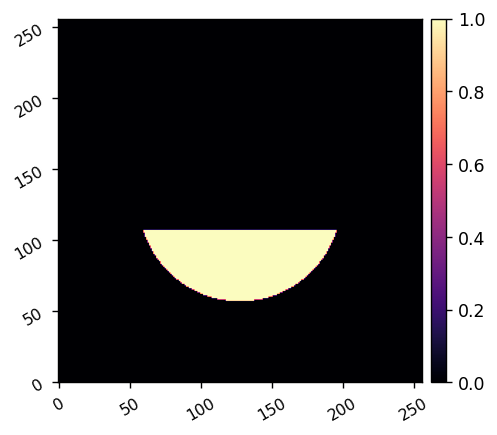

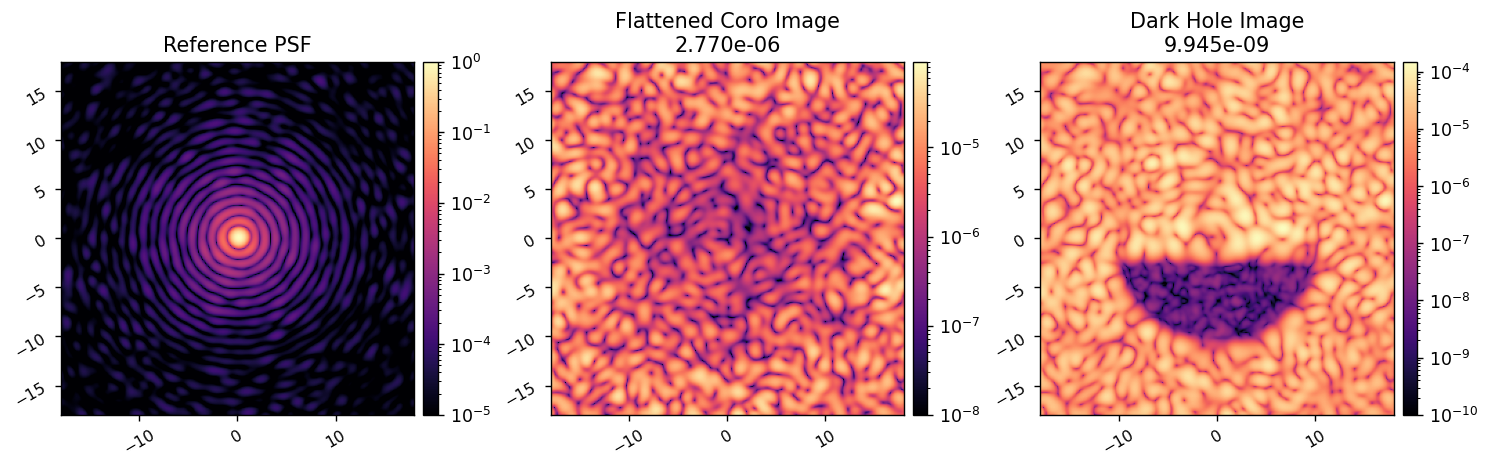

In [103]:
reload(esc)
M = esc.single(
    dm_ref=dm_flat,
)
M.wfes = wfes
M.npsf = 256

M.use_vortex = False
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = True
coro_im_flat = M.snap()

M.set_dm(dh_command, channel=3)
coro_im_dh = M.snap()

iwa = 3
owa = 10
coro_mask = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.psf_pixelscale_lamD,
    irad=iwa, 
    orad=owa,
    edge=iwa,
    rotation=90,
)
imshow1(coro_mask)

contrast_flat = utils.mean(coro_im_flat, coro_mask)
contrast_dh = utils.mean(coro_im_dh, coro_mask)

imshow3(
    ref_psf/M.Imax_ref, coro_im_flat, coro_im_dh,
    # ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask,
    f'Reference PSF',
    f'Flattened Coro Image\n{contrast_flat:.3e}',
    f'Dark Hole Image\n{contrast_dh:.3e}',
    lognorm=1,
    pxscl=M.psf_pixelscale_lamD,
    vmin1=1e-5, 
    vmin2=1e-8,
    vmin3=1e-10,
)

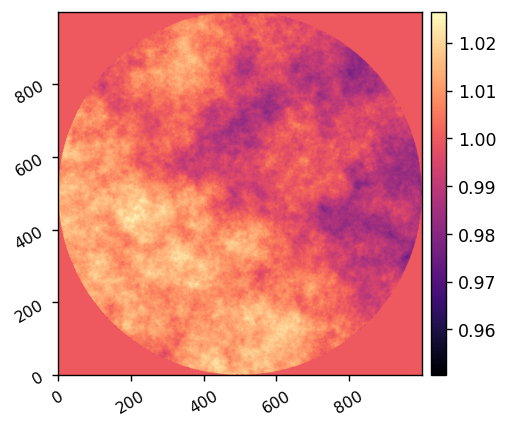

In [26]:
amp_map = wfes['m1'].amplitude
amp_map[amp_map<0.95] = 1
imshow1(amp_map)

In [101]:
def snap_bb(M, waves):
    bb_im = 0.0
    for wave in waves:
        M.wavelength = wave
        mono_im = M.snap()
        bb_im += mono_im
    return bb_im

[6.1750e-07 6.3375e-07 6.5000e-07 6.6625e-07 6.8250e-07] m


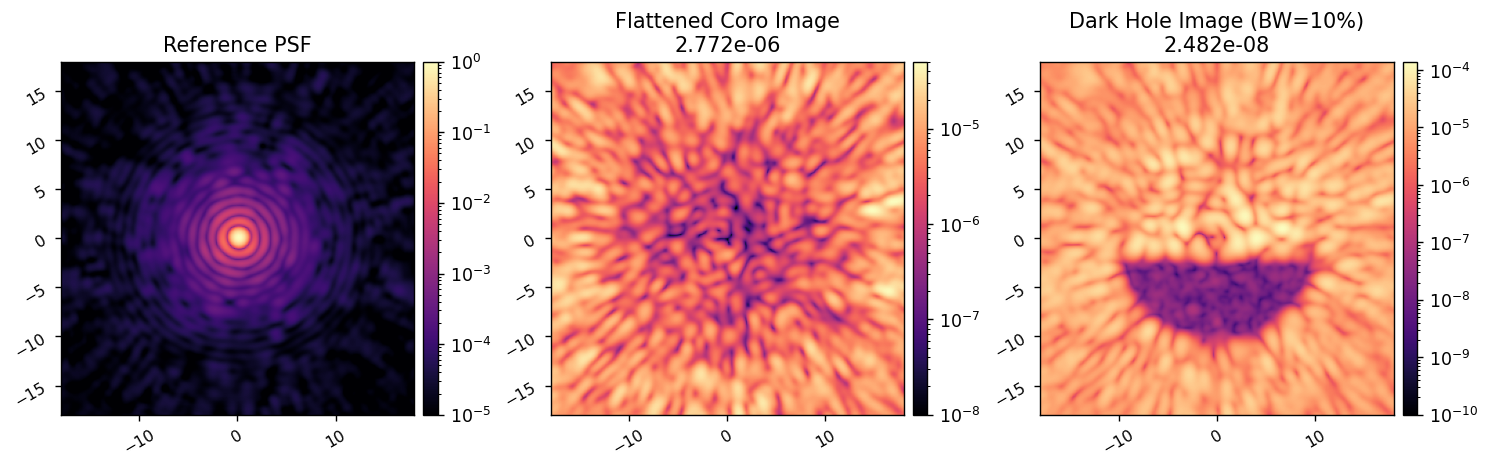

In [102]:
bw = 0.10
waves = np.linspace((1-bw/2)*M.wavelength_c, (1+bw/2)*M.wavelength_c, 5)
print(waves)

M.reset_dm()
M.use_vortex = False
ref_psf = snap_bb(M, waves)
Imax_ref = np.max(ref_psf)

M.use_vortex = True
coro_im_flat = snap_bb(M, waves) /Imax_ref

M.set_dm(dh_command, channel=3)
coro_im_dh = snap_bb(M, waves) /Imax_ref

contrast_flat = utils.mean(coro_im_flat, coro_mask)
contrast_dh = utils.mean(coro_im_dh, coro_mask)

imshow3(
    ref_psf/Imax_ref, coro_im_flat, coro_im_dh,
    # ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask,
    f'Reference PSF',
    f'Flattened Coro Image\n{contrast_flat:.3e}',
    f'Dark Hole Image (BW={bw*100:.0f}%)\n{contrast_dh:.3e}',
    lognorm=1,
    pxscl=M.psf_pixelscale_lamD,
    vmin1=1e-5, 
    vmin2=1e-8,
    vmin3=1e-10,
)

In [60]:
tilt = 1000*u.mas

x_field_bias = 1.100000000000000E-001
y_field_bias = 0
x_field_with_tilt = x_field_bias + tilt.to_value(u.degree)
y_field_with_tilt = y_field_bias + tilt.to_value(u.degree)
print(x_field_bias)

print(x_field_with_tilt)
print(y_field_with_tilt)

0.11
0.11027777777777778
0.00027777777777777783


In [38]:
tilt = 100*u.mas
tilt.to(u.degree)

<Quantity 2.77777778e-05 deg>

# Expected jitter/pointing error is 40mas before M4, 10mas bewteen M4 and FSM, and then 5mas for the rest.

# Perform an initial propagation to compute a reference PSF that is used to normalize the coronagraphic images. 

In [7]:
1.100000000000000E-001 + (50*u.mas).to(u.degree).value

0.11001388888888888

In [8]:
(50*u.mas).to(u.degree).value

1.3888888888888891e-05

In [61]:
import esc_fresnel
import os
from pathlib import Path
esc_fresnel_path = Path( os.path.dirname(esc_fresnel.__file__) ) 

In [104]:
start_row = 22
end_row = 128 - 22

surf_nums = np.loadtxt(
    esc_fresnel_path/'esc_ray_on_axis.txt', 
    skiprows=start_row, 
    max_rows=end_row, 
    usecols=0, 
    encoding="utf-16", 
    dtype=int,
)

xc_on_axis = np.loadtxt(esc_fresnel_path/'esc_ray_on_axis.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_on_axis = np.loadtxt(esc_fresnel_path/'esc_ray_on_axis.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)

xc_off_axis_x = np.loadtxt(esc_fresnel_path/'esc_ray_off_axis_x_100mas.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_off_axis_x = np.loadtxt(esc_fresnel_path/'esc_ray_off_axis_x_100mas.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)

xc_off_axis_y = np.loadtxt(esc_fresnel_path/'esc_ray_off_axis_y_100mas.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_off_axis_y = np.loadtxt(esc_fresnel_path/'esc_ray_off_axis_y_100mas.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)



In [105]:
reload(esc_optics)

seed = 1234
optic_keys = list(esc_optics.zemax_inds.keys())
beamwalk_matrices = {}
for i in range(len(optic_keys)):
    surf_num = esc_optics.zemax_inds[optic_keys[i]]
    surf_ind = np.where(surf_num==surf_nums)[0][0]
    print(optic_keys[i])
    print(surf_num, surf_ind)

    M_bw = np.array([
        [xc_off_axis_x[surf_ind] - xc_on_axis[surf_ind], xc_off_axis_y[surf_ind] - xc_on_axis[surf_ind]],
        [yc_off_axis_x[surf_ind] - yc_on_axis[surf_ind], yc_off_axis_y[surf_ind] - yc_on_axis[surf_ind]]
    ]) * u.mm/ (100*u.mas)
    print(M_bw)

    beamwalk_matrices.update({optic_keys[i]: M_bw})


m1
4 3
[[-5.79800001e-07 -1.00000079e-10]
 [ 0.00000000e+00 -5.80000001e-07]] mm / mas
m2
5 4
[[ 3.63267000e-05 -1.03900000e-07]
 [ 2.20000004e-09  3.65406000e-05]] mm / mas
m3
6 5
[[ 3.920100e-04 -1.548200e-06]
 [-2.643000e-07  3.928213e-04]] mm / mas
m4
9 8
[[-2.44680e-07  6.24770e-07]
 [ 5.66590e-07  3.46977e-06]] mm / mas
wcc_fp
12 11
[[-4.80732370e-04 -7.25330000e-06]
 [-7.26935360e-06 -4.87234212e-04]] mm / mas
oap1
21 20
[[-6.6755237e-04  1.6391500e-06]
 [ 1.6110000e-06 -6.6342110e-04]] mm / mas
fm1
23 22
[[-4.8935312e-04  1.1368300e-06]
 [ 1.1142000e-06 -5.1517780e-04]] mm / mas
pupil_mask
27 26
[[-2.85240421e-07 -9.36825043e-06]
 [ 7.71833134e-06  2.85781731e-07]] mm / mas
oap2
30 29
[[ 4.89050000e-07 -6.33778400e-05]
 [ 6.56712093e-05 -4.99861941e-07]] mm / mas
ifp1
32 31
[[ 2.77920900e-07 -9.88472321e-05]
 [ 9.52987251e-05 -2.78383590e-07]] mm / mas
oap3
35 34
[[ 1.02610000e-07 -1.17423790e-04]
 [ 1.17069335e-04 -1.15898646e-07]] mm / mas
fsm
38 37
[[-3.37766956e-07  3.65853

In [106]:
pointing = np.array([-120, -120])*u.mas
beamwalk_matrices['oap9'].dot(pointing)

<Quantity [-0.02493026,  0.02515731] mm>

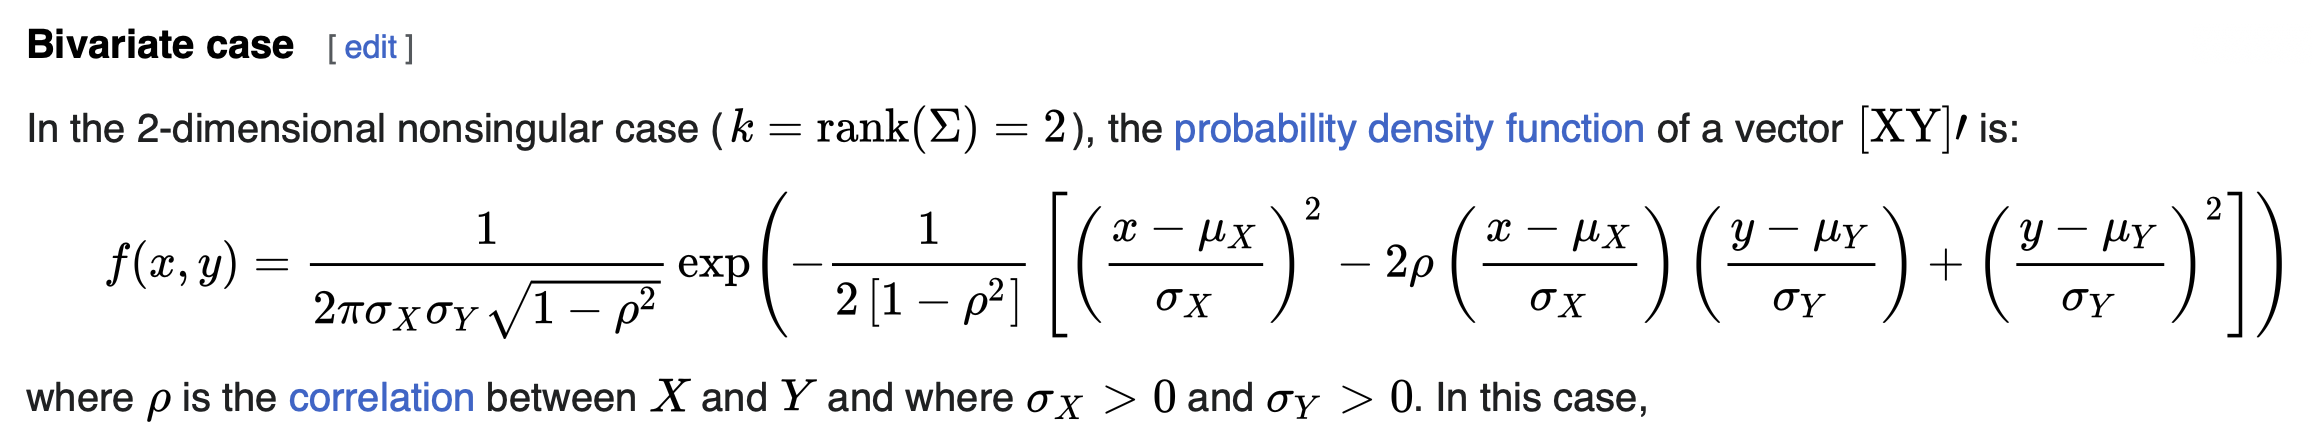


3600
(3600, 2)


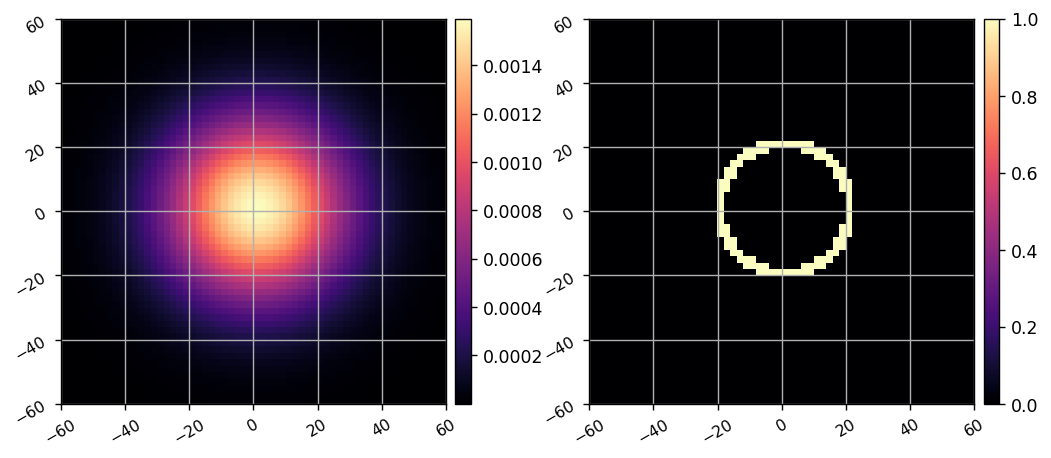

array(0.99456354)

In [107]:
jitter = 20*u.mas
pointing_sampling = jitter/10
Np = int(np.round( (6*jitter / pointing_sampling).decompose().value))
Nsamples = Np**2
print(Nsamples)

yc, xc = (xp.indices((Np, Np)) - Np//2)* pointing_sampling.to_value(u.mas)
rc = xp.sqrt(xc**2 + yc**2)
pdf_std = ( jitter.value-1.5 < rc ) * ( rc < jitter.value+2 )
pointing_samples = ensure_np_array ( xp.array([xc.flatten(), yc.flatten()]).T ) * u.mas
print(pointing_samples.shape)

amp = pointing_sampling.to_value(u.mas)**2 * 1/(2*xp.pi*jitter.to_value(u.mas)**2)
pointing_pdf = amp * xp.exp( -1/2 * ( (xc/jitter.to_value(u.mas))**2 + (yc/jitter.to_value(u.mas))**2 ) ) 
imshow2(
    pointing_pdf, pdf_std, 
    pxscl=pointing_sampling, 
    grid=True,
)

xp.sum(pointing_pdf)

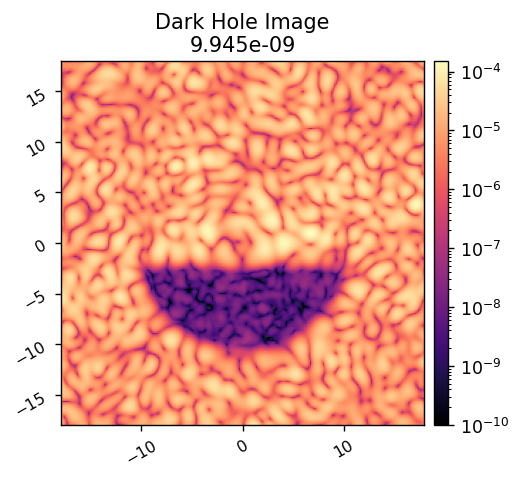

In [108]:
M.use_vortex = True
M.wfes = wfes
M.reset_dm()
M.set_dm(dh_command)
nominal_dh = M.snap()

contrast_dh = utils.mean(nominal_dh, coro_mask)

imshow1(
    nominal_dh,
    f'Dark Hole Image\n{contrast_dh:.3e}',
    lognorm=1,
    pxscl=M.psf_pixelscale_lamD,
    vmin=1e-10, 
)

In [80]:
jitter / 8

<Quantity 2.5 mas>

In [109]:
import time
import copy

quiet = 1
plot = 0
plot_all_wfes = 0

N_wfe_optics = len(wfes)
wfe_keys = list(wfes.keys())

shifts = []
total_im = 0.0

start = time.time()
for i in np.arange(Nsamples):
    # if i>10: break
    pointing = pointing_samples[i]
    amp = pointing_pdf.flatten()[i]
    if not quiet: print(i, pointing, amp)

    wfes_with_beamwalk = {}
    for j in range(N_wfe_optics): 
        # This for-loop shifts the WFE of each optics by the amount computed from the given pointing error 
        optic = wfe_keys[j]
        pxscl = wfes[optic].pixelscale
        Mbw = beamwalk_matrices[optic]
        if j<=3:
            eff_pointing = pointing
        elif 3 < j & j <= 8:
            eff_pointing = pointing/4 # reduce pointing error by 4 between M4 and FSM to get the effective pointing
        elif 8 < j :
            eff_pointing = pointing/10 # reduce pointing error by 8 after FSM to get the effective pointing
        
        shift = Mbw.dot(eff_pointing)
        shift_pix = shift.to_value(u.mm) / pxscl.to_value(u.mm/u.pix)
        if not quiet:
            print('\t', optic)
            print('\t', pxscl)
            print('\t', shift)
            print('\t', shift_pix)

        shifted_opd = copy.copy( xcipy.ndimage.shift( wfes[optic].opd, (shift_pix[0], shift_pix[1])) )
        shifted_amp = copy.copy( xcipy.ndimage.shift( wfes[optic].amplitude, (shift_pix[0], shift_pix[1])) )

        shifted_wfe = poppy.ArrayOpticalElement(
            opd=shifted_opd, 
            transmission=shifted_amp, 
            pixelscale=pxscl,
        )

        wfes_with_beamwalk.update({ 
            optic:shifted_wfe,
        })

        if plot_all_wfes: 
            amp_diff = wfes[optic].amplitude - wfes_with_beamwalk[optic].amplitude
            opd_diff = wfes[optic].opd - wfes_with_beamwalk[optic].opd
            imshow3(
                wfes[optic].amplitude, wfes_with_beamwalk[optic].amplitude, amp_diff, 
                f'{optic} Amplitude Error', f'Shifted {optic} Amplitude Error', 'Difference',
                npix=128,
            )
            imshow3(
                wfes[optic].opd, wfes_with_beamwalk[optic].opd, opd_diff, 
                f'{optic} OPD Error', f'Shifted {optic} OPD Error', 'Difference',
                npix=128,
            )

    M.wfes = wfes_with_beamwalk
    im = M.snap()
    contrast = utils.mean(im, coro_mask)
    total_im += amp * im

    if plot: 
        print(f"\tImage {i+1:d}/{Nsamples:d} computed in {time.time()-start:.3f}s")
        optic = 'oap9'
        imshow3(
            wfes[optic].opd, 
            wfes_with_beamwalk[optic].opd, 
            wfes[optic].opd-wfes_with_beamwalk[optic].opd,
            npix=100, 
        )
        imshow3(
            wfes[optic].amplitude, 
            wfes_with_beamwalk[optic].amplitude, 
            wfes[optic].amplitude-wfes_with_beamwalk[optic].amplitude,
            npix=100,
        )
        imshow1(
            im, 
            f'({pointing[0].value:.2f}, {pointing[1].value:.2f})\nContrast = {contrast:.3e}', 
            lognorm=True, vmin=1e-10,
        )
        clear_output(wait=True)
    else:
        print(f"\tImage {i+1:d}/{Nsamples:d} computed in {time.time()-start:.3f}s", end='')
        print("\r", end="")



        

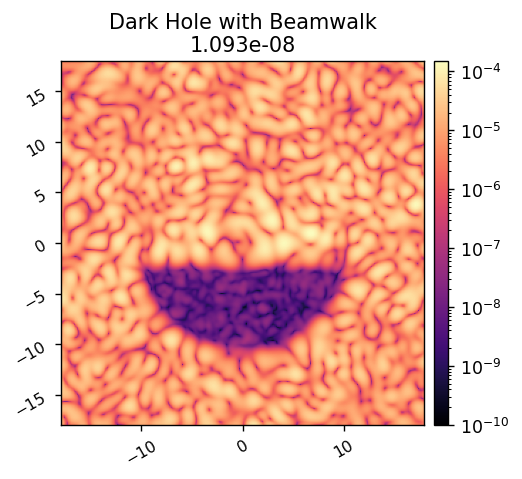

In [110]:
contrast_with_beamwalk = utils.mean(total_im, coro_mask)

imshow1(
    total_im,
    f'Dark Hole with Beamwalk\n{contrast_with_beamwalk:.3e}',
    lognorm=1,
    pxscl=M.psf_pixelscale_lamD,
    vmin=1e-10, 
)

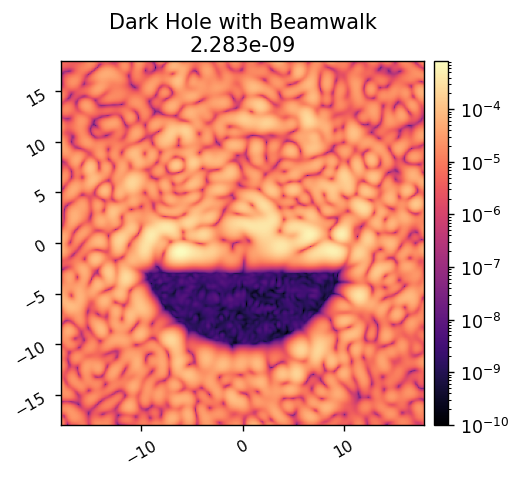

In [77]:
contrast_with_beamwalk = utils.mean(total_im, coro_mask)

imshow1(
    total_im,
    f'Dark Hole with Beamwalk\n{contrast_with_beamwalk:.3e}',
    lognorm=1,
    pxscl=M.psf_pixelscale_lamD,
    vmin=1e-10, 
)

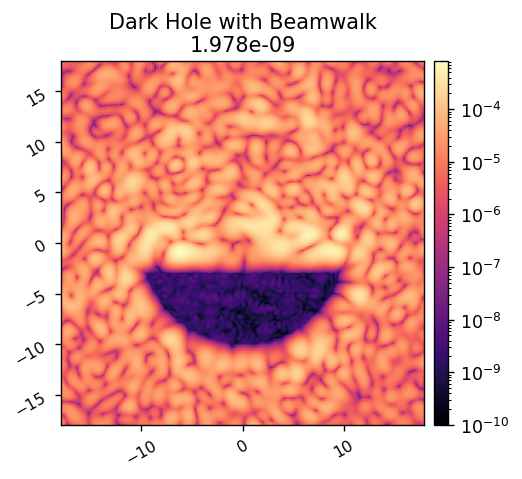

In [34]:
contrast_with_beamwalk = utils.mean(total_im, coro_mask)

imshow1(
    total_im,
    f'Dark Hole with Beamwalk\n{contrast_with_beamwalk:.3e}',
    lognorm=1,
    pxscl=M.psf_pixelscale_lamD,
    vmin=1e-10, 
)

In [15]:
xp.mean(total_im[control_mask.astype(bool)])

array(1.93894483e-09)